## Galaxy Morphology Classification with Deep Learning 

Applied Computer Vision for AI (AAI-521-04)

Alyona Kosobokova, Group 6


### Imports and Environment Setup

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import os
import warnings
import json
from datetime import datetime

warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    EfficientNetV2B3, EfficientNetB4, EfficientNetB7,
    ResNet50, ResNet152V2, DenseNet121, DenseNet201,
    InceptionResNetV2
)
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support,
    precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print("Environment Setup Complete")

Environment Setup Complete


### Data Loading

In [ ]:
DATA_PATH = 'Galaxy10_DECals.h5'

CLASS_NAMES = {
    0: 'Disturbed Galaxies',
    1: 'Merging Galaxies',
    2: 'Round Smooth Galaxies',
    3: 'In-between Round Smooth',
    4: 'Cigar Shaped Smooth',
    5: 'Barred Spiral Galaxies',
    6: 'Unbarred Tight Spiral',
    7: 'Unbarred Loose Spiral',
    8: 'Edge-on without Bulge',
    9: 'Edge-on with Bulge'
}

print("Loading Dataset...")
with h5py.File(DATA_PATH, 'r') as f:
    images = np.array(f['images'])
    labels = np.array(f['ans'])

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Data type: {images.dtype}")
print(f"Value range: [{images.min()}, {images.max()}]")
print(f"Total samples: {len(images):,}")

Loading Dataset...
Images shape: (17736, 256, 256, 3)
Labels shape: (17736,)
Data type: uint8
Value range: [0, 255]
Total samples: 17,736


### Class Distribution Analysis

Class Distribution:
 Class              Class Name  Count  Percentage
     2   Round Smooth Galaxies   2645       14.91
     7   Unbarred Loose Spiral   2628       14.82
     5  Barred Spiral Galaxies   2043       11.52
     3 In-between Round Smooth   2027       11.43
     9      Edge-on with Bulge   1873       10.56
     1        Merging Galaxies   1853       10.45
     6   Unbarred Tight Spiral   1829       10.31
     8   Edge-on without Bulge   1423        8.02
     0      Disturbed Galaxies   1081        6.09
     4     Cigar Shaped Smooth    334        1.88

Imbalance Ratio: 7.92:1


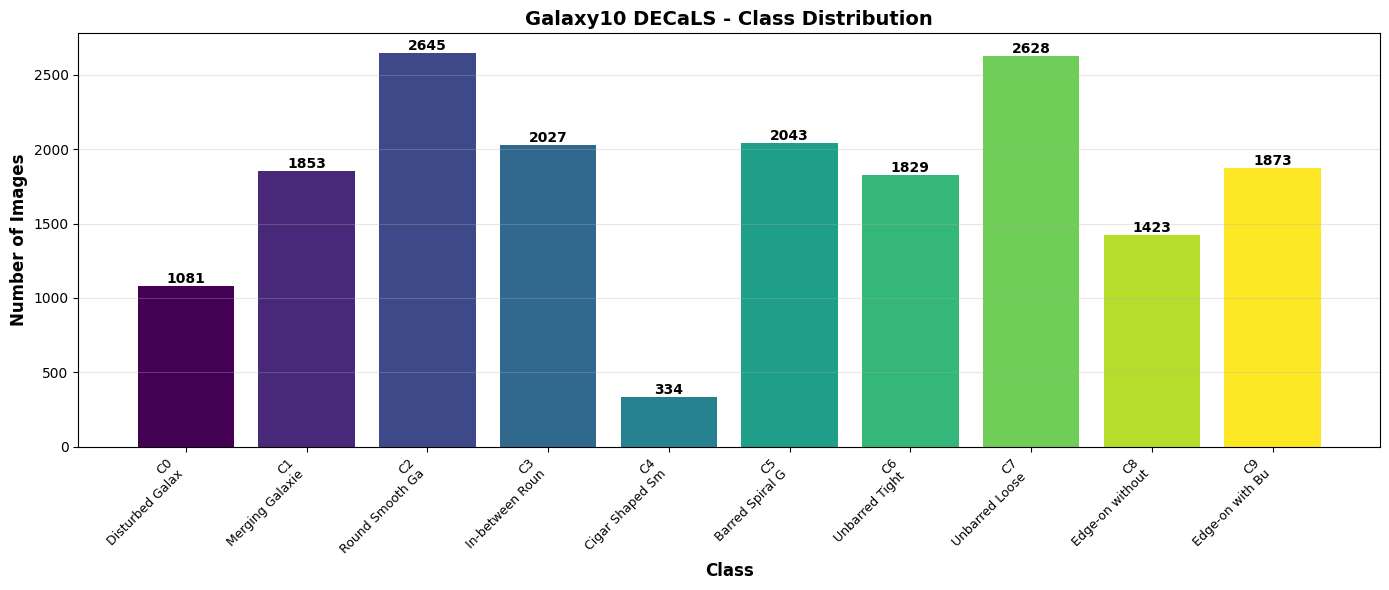

In [ ]:
unique, counts = np.unique(labels, return_counts=True)
class_dist = pd.DataFrame({
    'Class': unique,
    'Class Name': [CLASS_NAMES[i] for i in unique],
    'Count': counts,
    'Percentage': (counts / len(labels) * 100).round(2)
}).sort_values('Count', ascending=False)

print("Class Distribution:")
print(class_dist.to_string(index=False))
print(f"\nImbalance Ratio: {class_dist.iloc[0]['Count'] / class_dist.iloc[-1]['Count']:.2f}:1")

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(10), [counts[i] for i in range(10)],
              color=plt.cm.viridis(np.linspace(0, 1, 10)))
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_title('Galaxy10 DECaLS - Class Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(range(10))
ax.set_xticklabels([f"C{i}\n{CLASS_NAMES[i][:15]}" for i in range(10)],
                    rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

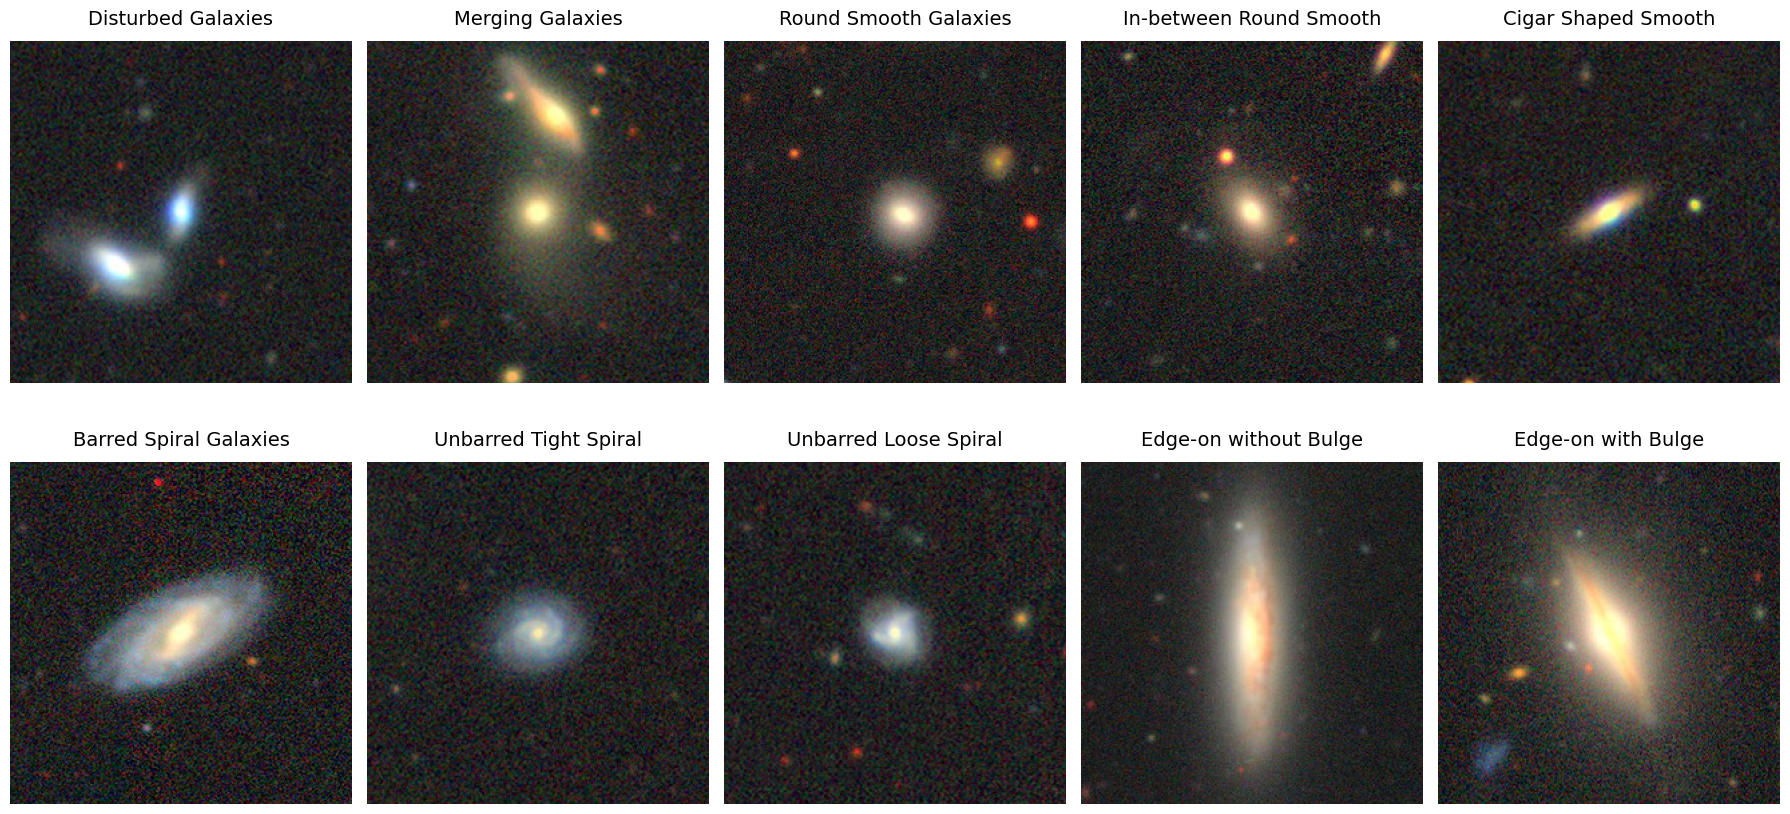

In [6]:
NUM_CLASSES = 10

# pick one random index per class
rand_idx = [np.random.choice(np.where(labels == c)[0]) for c in range(NUM_CLASSES)]

plt.figure(figsize=(18, 9))

for j, idx in enumerate(rand_idx):
    ax = plt.subplot(2, 5, j + 1)

    img = images[idx].astype(np.float32) / 255.0
    ax.imshow(img)
    ax.axis("off")

    # title of each class centered above image
    ax.set_title(CLASS_NAMES[labels[idx]], fontsize=14, pad=12)

plt.tight_layout()
plt.show()

### Image Properties Analysis

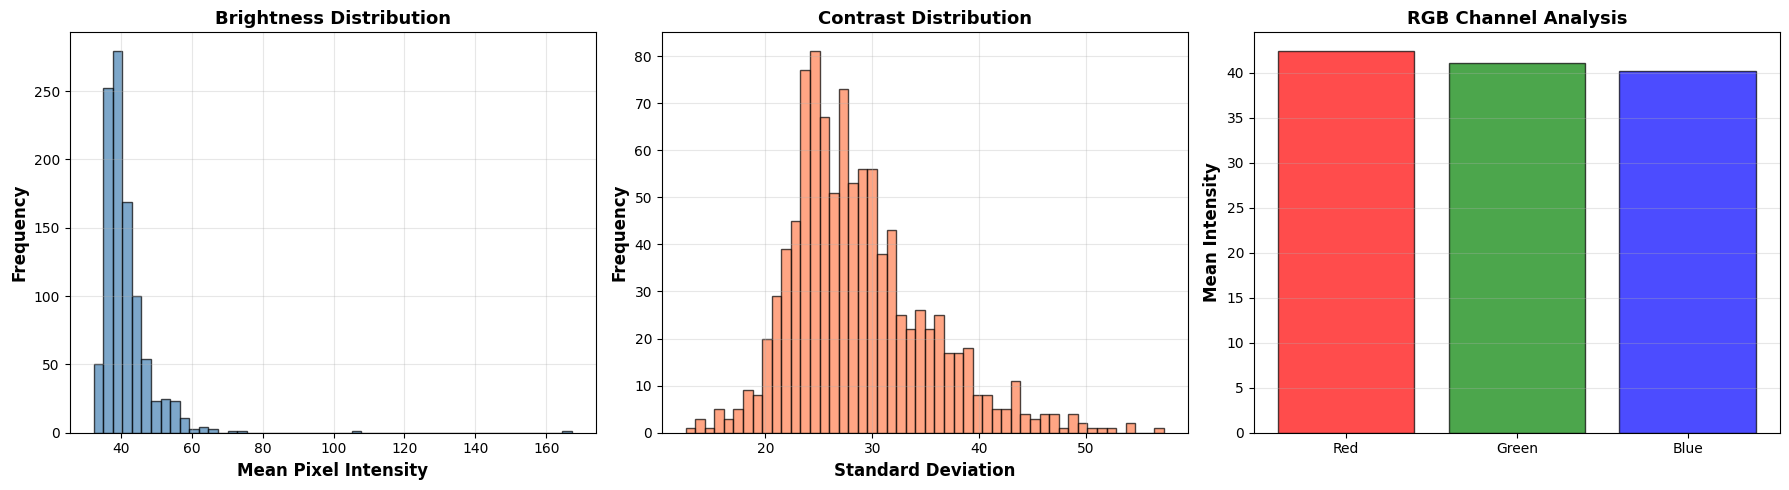

Mean Brightness: 41.22 ± 7.22
Mean Std Dev: 28.73 ± 6.48
RGB Means: R=42.38, G=41.08, B=40.19


In [ ]:
sample_indices = np.random.choice(len(images), 1000, replace=False)
sample_images = images[sample_indices]

mean_brightness = sample_images.mean(axis=(1, 2, 3))
std_brightness = sample_images.std(axis=(1, 2, 3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(mean_brightness, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Mean Pixel Intensity', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Brightness Distribution', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(std_brightness, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Standard Deviation', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Contrast Distribution', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

r_mean = sample_images[:, :, :, 0].mean()
g_mean = sample_images[:, :, :, 1].mean()
b_mean = sample_images[:, :, :, 2].mean()
axes[2].bar(['Red', 'Green', 'Blue'], [r_mean, g_mean, b_mean],
           color=['red', 'green', 'blue'], alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Mean Intensity', fontsize=12, fontweight='bold')
axes[2].set_title('RGB Channel Analysis', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('image_properties.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Mean Brightness: {mean_brightness.mean():.2f} ± {mean_brightness.std():.2f}")
print(f"Mean Std Dev: {std_brightness.mean():.2f} ± {std_brightness.std():.2f}")
print(f"RGB Means: R={r_mean:.2f}, G={g_mean:.2f}, B={b_mean:.2f}")

### Data Preprocessing and Splitting


In [ ]:

X = images.astype('float32')
y = labels

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=SEED, stratify=y_temp
)

print("Dataset Split:")
print(f"Train: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("\nClass Weights:")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls} ({CLASS_NAMES[cls][:20]}...): {weight:.3f}")

Dataset Split:
Train: 14,188 samples (80.0%)
Val:   1,774 samples (10.0%)
Test:  1,774 samples (10.0%)

Class Weights:
  Class 0 (Disturbed Galaxies...): 1.640
  Class 1 (Merging Galaxies...): 0.957
  Class 2 (Round Smooth Galaxie...): 0.671
  Class 3 (In-between Round Smo...): 0.875
  Class 4 (Cigar Shaped Smooth...): 5.314
  Class 5 (Barred Spiral Galaxi...): 0.868
  Class 6 (Unbarred Tight Spira...): 0.970
  Class 7 (Unbarred Loose Spira...): 0.675
  Class 8 (Edge-on without Bulg...): 1.246
  Class 9 (Edge-on with Bulge...): 0.946


### Data Augmentation Configuration

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow(X_train, y_train, batch_size=32, seed=SEED)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32, seed=SEED)

print("Data Augmentation Setup Complete")
print(f"Training batches per epoch: {len(train_generator)}")
print(f"Validation batches per epoch: {len(val_generator)}")

Data Augmentation Setup Complete
Training batches per epoch: 444
Validation batches per epoch: 56


### Baseline CNN - Model Architecture


In [ ]:
def create_baseline_cnn(input_shape=(256, 256, 3), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', dtype='float32')
    ])

    return model

baseline_cnn = create_baseline_cnn()
baseline_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,444,650 (5.51 MB)

 Trainable params: 1,441,194 (5.50 MB)

 Non-trainable params: 3,456 (13.50 KB)

### Baseline CNN - Training

In [ ]:
baseline_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_callbacks = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('baseline_cnn_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Training Baseline CNN...")
baseline_history = baseline_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=baseline_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

with open('baseline_cnn_history.json', 'w') as f:
    json.dump(baseline_history.history, f, indent=4)

print("\nBaseline CNN Training Complete")
print(f"Best Val Accuracy: {max(baseline_history.history['val_accuracy'])*100:.2f}%")

Training Baseline CNN...
Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.1586 - loss: 2.9438
Epoch 1: val_accuracy improved from -inf to 0.16404, saving model to baseline_cnn_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 295s 519ms/step - accuracy: 0.1587 - loss: 2.9431 - val_accuracy: 0.1640 - val_loss: 3.9831 - learning_rate: 0.0010
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.2616 - loss: 2.1074
Epoch 2: val_accuracy improved from 0.16404 to 0.25366, saving model to baseline_cnn_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 179s 404ms/step - accuracy: 0.2617 - loss: 2.1072 - val_accuracy: 0.2537 - val_loss: 2.1441 - learning_rate: 0.0010
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.3031 - loss: 1.8972
Epoch 3: val_accuracy improved from 0.25366 to 0.41545, saving model to baseline_cnn_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 180s 404ms/step - accuracy: 0.3032 - loss: 1.8970 - val_accuracy: 0.4154 - val_loss: 1.5918 - learning_rate

### Fine-tuning


In [ ]:
# Load the best model from phase 1
baseline_cnn = keras.models.load_model('baseline_cnn_best.keras')

# Unfreeze some layers for fine-tuning (last 8 layers)
for layer in baseline_cnn.layers[:-8]:
    layer.trainable = False
for layer in baseline_cnn.layers[-8:]:
    layer.trainable = True

# Recompile with lower learning rate
baseline_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_callbacks_finetune = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint('baseline_cnn_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Fine-tuning Baseline CNN...")
print(f"Trainable layers: {sum([1 for layer in baseline_cnn.layers if layer.trainable])}/{len(baseline_cnn.layers)}")

baseline_history_finetune = baseline_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=baseline_callbacks_finetune,
    class_weight=class_weight_dict,
    verbose=1
)

with open('baseline_cnn_finetune_history.json', 'w') as f:
    json.dump(baseline_history_finetune.history, f, indent=4)

print("\nCNN Fine-tuning Complete")
print(f"Best Val Accuracy: {max(baseline_history_finetune.history['val_accuracy'])*100:.2f}%")

Fine-tuning Baseline CNN...
Trainable layers: 8/32
Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.8170 - loss: 0.5151
Epoch 1: val_accuracy improved from -inf to 0.82187, saving model to baseline_cnn_finetuned.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 194s 420ms/step - accuracy: 0.8170 - loss: 0.5151 - val_accuracy: 0.8219 - val_loss: 0.5085 - learning_rate: 1.0000e-05
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8147 - loss: 0.5440
Epoch 2: val_accuracy improved from 0.82187 to 0.82469, saving model to baseline_cnn_finetuned.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 179s 403ms/step - accuracy: 0.8147 - loss: 0.5439 - val_accuracy: 0.8247 - val_loss: 0.5057 - learning_rate: 1.0000e-05
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8200 - loss: 0.5452
Epoch 3: val_accuracy did not improve from 0.82469
444/444 ━━━━━━━━━━━━━━━━━━━━ 178s 400ms/step - accuracy: 0.8200 - loss: 0.5452 - val_accuracy: 0.8241 - val_loss: 0.5076 - learning_rate:

### CNN - Evaluation


In [ ]:
X_test_norm = X_test / 255.0

# Evaluate Original Model
print("BASELINE CNN - ORIGINAL MODEL")
baseline_cnn_original = keras.models.load_model('baseline_cnn_best.keras')

baseline_predictions = baseline_cnn_original.predict(X_test_norm, batch_size=32, verbose=1)
baseline_pred_classes = np.argmax(baseline_predictions, axis=1)

baseline_acc = accuracy_score(y_test, baseline_pred_classes)
baseline_precision = precision_score(y_test, baseline_pred_classes, average='weighted')
baseline_recall = recall_score(y_test, baseline_pred_classes, average='weighted')
baseline_f1 = f1_score(y_test, baseline_pred_classes, average='weighted')

print("\nOriginal Model Test Results:")
print(f"Accuracy:  {baseline_acc*100:.2f}%")
print(f"Precision: {baseline_precision*100:.2f}%")
print(f"Recall:    {baseline_recall*100:.2f}%")
print(f"F1-Score:  {baseline_f1*100:.2f}%")

# Evaluate Fine-tuned Model
print("BASELINE CNN - FINE-TUNED MODEL")
baseline_cnn_finetuned = keras.models.load_model('baseline_cnn_finetuned.keras')

baseline_predictions_ft = baseline_cnn_finetuned.predict(X_test_norm, batch_size=32, verbose=1)
baseline_pred_classes_ft = np.argmax(baseline_predictions_ft, axis=1)

baseline_acc_ft = accuracy_score(y_test, baseline_pred_classes_ft)
baseline_precision_ft = precision_score(y_test, baseline_pred_classes_ft, average='weighted')
baseline_recall_ft = recall_score(y_test, baseline_pred_classes_ft, average='weighted')
baseline_f1_ft = f1_score(y_test, baseline_pred_classes_ft, average='weighted')

print("\nFine-tuned Model Test Results:")
print(f"Accuracy:  {baseline_acc_ft*100:.2f}%")
print(f"Precision: {baseline_precision_ft*100:.2f}%")
print(f"Recall:    {baseline_acc_ft*100:.2f}%")
print(f"F1-Score:  {baseline_f1_ft*100:.2f}%")

# Save Results
baseline_results = {
    'original': {
        'model': 'Baseline CNN (Original)',
        'accuracy': float(baseline_acc),
        'precision': float(baseline_precision),
        'recall': float(baseline_recall),
        'f1_score': float(baseline_f1)
    },
    'finetuned': {
        'model': 'Baseline CNN (Fine-tuned)',
        'accuracy': float(baseline_acc_ft),
        'precision': float(baseline_precision_ft),
        'recall': float(baseline_recall_ft),
        'f1_score': float(baseline_f1_ft)
    },
    'improvement': {
        'accuracy': float(baseline_acc_ft - baseline_acc),
        'precision': float(baseline_precision_ft - baseline_precision),
        'recall': float(baseline_recall_ft - baseline_recall),
        'f1_score': float(baseline_f1_ft - baseline_f1)
    }
}

with open('baseline_cnn_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=4)

BASELINE CNN - ORIGINAL MODEL
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step

Original Model Test Results:
Accuracy:  82.02%
Precision: 82.90%
Recall:    82.02%
F1-Score:  81.48%
BASELINE CNN - FINE-TUNED MODEL
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step

Fine-tuned Model Test Results:
Accuracy:  82.13%
Precision: 83.15%
Recall:    82.13%
F1-Score:  81.62%


### Baseline CNN - Training Curves

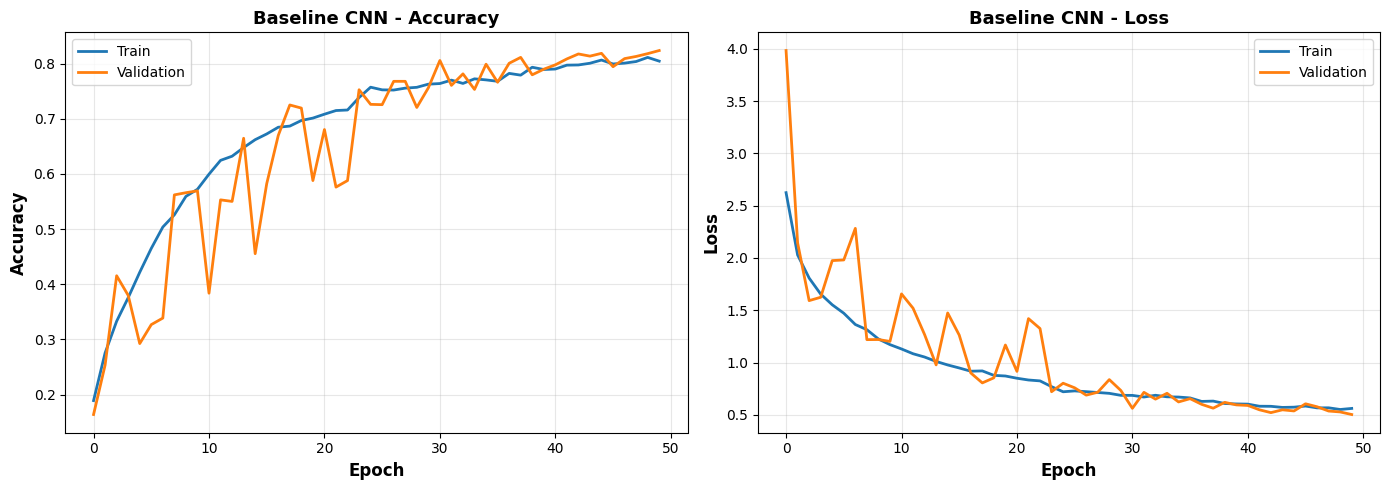

In [ ]:
combined_acc = baseline_history.history['accuracy'] + baseline_history_finetune.history['accuracy']
combined_val_acc = baseline_history.history['val_accuracy'] + baseline_history_finetune.history['val_accuracy']
combined_loss = baseline_history.history['loss'] + baseline_history_finetune.history['loss']
combined_val_loss = baseline_history.history['val_loss'] + baseline_history_finetune.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(combined_acc, label='Train', linewidth=2)
axes[0].plot(combined_val_acc, label='Validation', linewidth=2)
axes[0].axvline(x=len(baseline_history.history['accuracy']), color='red',
                linestyle='--', linewidth=1.5, label='Fine-tuning Start')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Baseline CNN - Accuracy', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(combined_loss, label='Train', linewidth=2)
axes[1].plot(combined_val_loss, label='Validation', linewidth=2)
axes[1].axvline(x=len(baseline_history.history['loss']), color='red',
                linestyle='--', linewidth=1.5, label='Fine-tuning Start')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Baseline CNN - Loss', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_cnn_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total epochs: {len(combined_acc)}")
print(f"Phase 1 epochs: {len(baseline_history.history['accuracy'])}")
print(f"Phase 2 epochs: {len(baseline_history_finetune.history['accuracy'])}")
print(f"Best validation accuracy: {max(combined_val_acc)*100:.2f}%")

### EfficientNetV2B3 - Model Architecture

In [ ]:
def create_efficientnet_model(input_shape=(256, 256, 3), num_classes=10):
    base_model = EfficientNetV2B3(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

efficientnet_model, efficientnet_base = create_efficientnet_model()
efficientnet_model.summary()

print(f"\nTotal layers: {len(efficientnet_model.layers)}")
print(f"Trainable layers: {sum([1 for layer in efficientnet_model.layers if layer.trainable])}")

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_97"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 8, 8, 1536)     │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,854,536 (52.85 MB)

 Trainable params: 922,378 (3.52 MB)

 Non-trainable params: 12,932,158 (49.33 MB)


Total layers: 10
Trainable layers: 9


###  EfficientNetV2B3 - Phase 1 Training (Frozen Base)


In [ ]:
efficientnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

efficientnet_callbacks_p1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('efficientnet_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("EfficientNetV2B3 - Phase 1 Training (Frozen Base)...")
efficientnet_history_p1 = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=efficientnet_callbacks_p1,
    class_weight=class_weight_dict,
    verbose=1
)

with open('efficientnet_phase1_history.json', 'w') as f:
    json.dump(efficientnet_history_p1.history, f, indent=4)

print(f"\nPhase 1 Best Val Accuracy: {max(efficientnet_history_p1.history['val_accuracy'])*100:.2f}%")

EfficientNetV2B3 - Phase 1 Training (Frozen Base)...
Epoch 1/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.1014 - loss: 3.0641
Epoch 1: val_accuracy improved from -inf to 0.01860, saving model to efficientnet_phase1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 361s 653ms/step - accuracy: 0.1014 - loss: 3.0635 - val_accuracy: 0.0186 - val_loss: 2.4236 - learning_rate: 0.0010
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.0942 - loss: 2.5985
Epoch 2: val_accuracy improved from 0.01860 to 0.08005, saving model to efficientnet_phase1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 181s 407ms/step - accuracy: 0.0942 - loss: 2.5983 - val_accuracy: 0.0800 - val_loss: 2.3348 - learning_rate: 0.0010
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.0952 - loss: 2.4343
Epoch 3: val_accuracy improved from 0.08005 to 0.11443, saving model to efficientnet_phase1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 181s 408ms/step - accuracy: 0.0952 - loss: 2.4343 - val_accuracy: 0.1144 

### EfficientNetV2B3 - Phase 2 Fine-tuning

In [ ]:
efficientnet_base.trainable = True
for layer in efficientnet_base.layers[:-30]:
    layer.trainable = False

efficientnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

efficientnet_callbacks_p2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint('efficientnet_phase2.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("EfficientNetV2B3 - Phase 2 Fine-tuning...")
efficientnet_history_p2 = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=efficientnet_callbacks_p2,
    class_weight=class_weight_dict,
    verbose=1
)

with open('efficientnet_phase2_history.json', 'w') as f:
    json.dump(efficientnet_history_p2.history, f, indent=4)

print(f"\nPhase 2 Best Val Accuracy: {max(efficientnet_history_p2.history['val_accuracy'])*100:.2f}%")

EfficientNetV2B3 - Phase 2 Fine-tuning...
Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.0952 - loss: 2.3320
Epoch 1: val_accuracy improved from -inf to 0.14825, saving model to efficientnet_phase2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 361s 640ms/step - accuracy: 0.0952 - loss: 2.3320 - val_accuracy: 0.1483 - val_loss: 2.3011 - learning_rate: 1.0000e-05
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.0894 - loss: 2.3188
Epoch 2: val_accuracy did not improve from 0.14825
444/444 ━━━━━━━━━━━━━━━━━━━━ 180s 406ms/step - accuracy: 0.0894 - loss: 2.3188 - val_accuracy: 0.1483 - val_loss: 2.2997 - learning_rate: 1.0000e-05
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.0830 - loss: 2.3298
Epoch 3: val_accuracy did not improve from 0.14825
444/444 ━━━━━━━━━━━━━━━━━━━━ 180s 404ms/step - accuracy: 0.0830 - loss: 2.3297 - val_accuracy: 0.0186 - val_loss: 2.3026 - learning_rate: 1.0000e-05
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/s

### EfficientNetV2B3 - Evaluation

In [ ]:
efficientnet_model = keras.models.load_model('efficientnet_phase2.keras')

efficientnet_predictions = efficientnet_model.predict(X_test_norm, batch_size=32, verbose=1)
efficientnet_pred_classes = np.argmax(efficientnet_predictions, axis=1)

efficientnet_acc = accuracy_score(y_test, efficientnet_pred_classes)
efficientnet_precision = precision_score(y_test, efficientnet_pred_classes, average='weighted')
efficientnet_recall = recall_score(y_test, efficientnet_pred_classes, average='weighted')
efficientnet_f1 = f1_score(y_test, efficientnet_pred_classes, average='weighted')

print("EfficientNetV2B3 Test Results:")
print(f"Accuracy:  {efficientnet_acc*100:.2f}%")
print(f"Precision: {efficientnet_precision*100:.2f}%")
print(f"Recall:    {efficientnet_recall*100:.2f}%")
print(f"F1-Score:  {efficientnet_f1*100:.2f}%")

efficientnet_results = {
    'model': 'EfficientNetV2B3',
    'accuracy': float(efficientnet_acc),
    'precision': float(efficientnet_precision),
    'recall': float(efficientnet_recall),
    'f1_score': float(efficientnet_f1)
}

with open('efficientnet_results.json', 'w') as f:
    json.dump(efficientnet_results, f, indent=4)

56/56 ━━━━━━━━━━━━━━━━━━━━ 51s 465ms/step
EfficientNetV2B3 Test Results:
Accuracy:  14.60%
Precision: 2.85%
Recall:    14.60%
F1-Score:  4.16%


### EfficientNetV2B3 - Training Curves


In [ ]:
combined_acc = efficientnet_history_p1.history['accuracy'] + efficientnet_history_p2.history['accuracy']
combined_val_acc = efficientnet_history_p1.history['val_accuracy'] + efficientnet_history_p2.history['val_accuracy']
combined_loss = efficientnet_history_p1.history['loss'] + efficientnet_history_p2.history['loss']
combined_val_loss = efficientnet_history_p1.history['val_loss'] + efficientnet_history_p2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(combined_acc, label='Train', linewidth=2)
axes[0].plot(combined_val_acc, label='Validation', linewidth=2)
axes[0].axvline(x=len(efficientnet_history_p1.history['accuracy']), color='red',
                linestyle='--', label='Fine-tuning Start')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('EfficientNetV2B3 - Accuracy', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(combined_loss, label='Train', linewidth=2)
axes[1].plot(combined_val_loss, label='Validation', linewidth=2)
axes[1].axvline(x=len(efficientnet_history_p1.history['loss']), color='red',
                linestyle='--', label='Fine-tuning Start')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('EfficientNetV2B3 - Loss', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('efficientnet_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### 3-Model Ensemble - Focal Loss Definition

In [ ]:
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=10)

        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * y_true_one_hot * tf.pow(1 - y_pred, gamma)

        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=-1)

    return focal_loss_fixed

print("Focal Loss Function Defined")

Focal Loss Function Defined


### 3-Model Ensemble - Architecture

In [ ]:
def create_ensemble_model_3(input_shape=(256, 256, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Model 1: EfficientNetB4
    base1 = EfficientNetB4(weights='imagenet', include_top=False, input_shape=input_shape)
    base1.trainable = False
    x1 = base1(inputs)
    x1 = layers.GlobalAveragePooling2D()(x1)
    x1 = layers.Dense(256, activation='relu')(x1)
    x1 = layers.Dropout(0.4)(x1)

    # Model 2: ResNet50
    base2 = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base2.trainable = False
    x2 = base2(inputs)
    x2 = layers.GlobalAveragePooling2D()(x2)
    x2 = layers.Dense(256, activation='relu')(x2)
    x2 = layers.Dropout(0.4)(x2)

    # Model 3: DenseNet121
    base3 = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    base3.trainable = False
    x3 = base3(inputs)
    x3 = layers.GlobalAveragePooling2D()(x3)
    x3 = layers.Dense(256, activation='relu')(x3)
    x3 = layers.Dropout(0.4)(x3)

    # Combine
    combined = layers.concatenate([x1, x2, x3])
    combined = layers.Dense(512, activation='relu')(combined)
    combined = layers.BatchNormalization()(combined)
    combined = layers.Dropout(0.5)(combined)
    combined = layers.Dense(256, activation='relu')(combined)
    combined = layers.BatchNormalization()(combined)
    combined = layers.Dropout(0.4)(combined)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(combined)

    model = models.Model(inputs, outputs)
    return model, [base1, base2, base3]

ensemble3_model, ensemble3_bases = create_ensemble_model_3()
print("3-Model Ensemble Created")
print(f"Total parameters: {ensemble3_model.count_params():,}")

3-Model Ensemble Created
Total parameters: 50,075,689


### 3-Model Ensemble - Phase 1 Training

In [ ]:
ensemble3_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

ensemble3_callbacks_p1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('ensemble3_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("3-Model Ensemble - Phase 1 Training...")
ensemble3_history_p1 = ensemble3_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=ensemble3_callbacks_p1,
    class_weight=class_weight_dict,
    verbose=1
)

with open('ensemble3_phase1_history.json', 'w') as f:
    json.dump(ensemble3_history_p1.history, f, indent=4)

print(f"\nPhase 1 Best Val Accuracy: {max(ensemble3_history_p1.history['val_accuracy'])*100:.2f}%")

3-Model Ensemble - Phase 1 Training...
Epoch 1/25
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.3439 - loss: 0.3791
Epoch 1: val_accuracy improved from -inf to 0.61612, saving model to ensemble3_phase1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 517s 848ms/step - accuracy: 0.3441 - loss: 0.3790 - val_accuracy: 0.6161 - val_loss: 0.1816 - learning_rate: 0.0010
Epoch 2/25
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5223 - loss: 0.2159
Epoch 2: val_accuracy did not improve from 0.61612
444/444 ━━━━━━━━━━━━━━━━━━━━ 181s 408ms/step - accuracy: 0.5223 - loss: 0.2159 - val_accuracy: 0.5998 - val_loss: 0.1618 - learning_rate: 0.0010
Epoch 3/25
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.5655 - loss: 0.1895
Epoch 3: val_accuracy improved from 0.61612 to 0.64487, saving model to ensemble3_phase1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 188s 422ms/step - accuracy: 0.5655 - loss: 0.1895 - val_accuracy: 0.6449 - val_loss: 0.1439 - learning_rate: 0.0010
Epoch 4/25
444/444 ━━━━━

### 3-Model Ensemble - Phase 2 Fine-tuning



In [ ]:
for base in ensemble3_bases:
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False

ensemble3_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

ensemble3_callbacks_p2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint('ensemble3_phase2.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("3-Model Ensemble - Phase 2 Fine-tuning...")
ensemble3_history_p2 = ensemble3_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=ensemble3_callbacks_p2,
    class_weight=class_weight_dict,
    verbose=1
)

with open('ensemble3_phase2_history.json', 'w') as f:
    json.dump(ensemble3_history_p2.history, f, indent=4)

print(f"\nPhase 2 Best Val Accuracy: {max(ensemble3_history_p2.history['val_accuracy'])*100:.2f}%")

3-Model Ensemble - Phase 2 Fine-tuning...
Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.7264 - loss: 0.1103
Epoch 1: val_accuracy improved from -inf to 0.73281, saving model to ensemble3_phase2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 517s 845ms/step - accuracy: 0.7264 - loss: 0.1103 - val_accuracy: 0.7328 - val_loss: 0.1081 - learning_rate: 1.0000e-05
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.7355 - loss: 0.1092
Epoch 2: val_accuracy improved from 0.73281 to 0.73675, saving model to ensemble3_phase2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 190s 428ms/step - accuracy: 0.7355 - loss: 0.1092 - val_accuracy: 0.7368 - val_loss: 0.1059 - learning_rate: 1.0000e-05
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.7313 - loss: 0.1043
Epoch 3: val_accuracy did not improve from 0.73675
444/444 ━━━━━━━━━━━━━━━━━━━━ 183s 412ms/step - accuracy: 0.7313 - loss: 0.1043 - val_accuracy: 0.7294 - val_loss: 0.1054 - learning_rate: 1.0000e-05
Epoch 4/5

### 3-Model Ensemble - Evaluation

In [ ]:
ensemble3_model = keras.models.load_model('ensemble3_phase2.keras',
                                          custom_objects={'focal_loss_fixed': focal_loss(gamma=2.0, alpha=0.25)})

ensemble3_predictions = ensemble3_model.predict(X_test_norm, batch_size=32, verbose=1)
ensemble3_pred_classes = np.argmax(ensemble3_predictions, axis=1)

ensemble3_acc = accuracy_score(y_test, ensemble3_pred_classes)
ensemble3_precision = precision_score(y_test, ensemble3_pred_classes, average='weighted')
ensemble3_recall = recall_score(y_test, ensemble3_pred_classes, average='weighted')
ensemble3_f1 = f1_score(y_test, ensemble3_pred_classes, average='weighted')

print("3-Model Ensemble Test Results:")
print(f"Accuracy:  {ensemble3_acc*100:.2f}%")
print(f"Precision: {ensemble3_precision*100:.2f}%")
print(f"Recall:    {ensemble3_recall*100:.2f}%")
print(f"F1-Score:  {ensemble3_f1*100:.2f}%")

ensemble3_results = {
    'model': '3-Model Ensemble (Focal Loss)',
    'accuracy': float(ensemble3_acc),
    'precision': float(ensemble3_precision),
    'recall': float(ensemble3_recall),
    'f1_score': float(ensemble3_f1)
}

with open('ensemble3_results.json', 'w') as f:
    json.dump(ensemble3_results, f, indent=4)

### 3-Model Ensemble - Training Curves

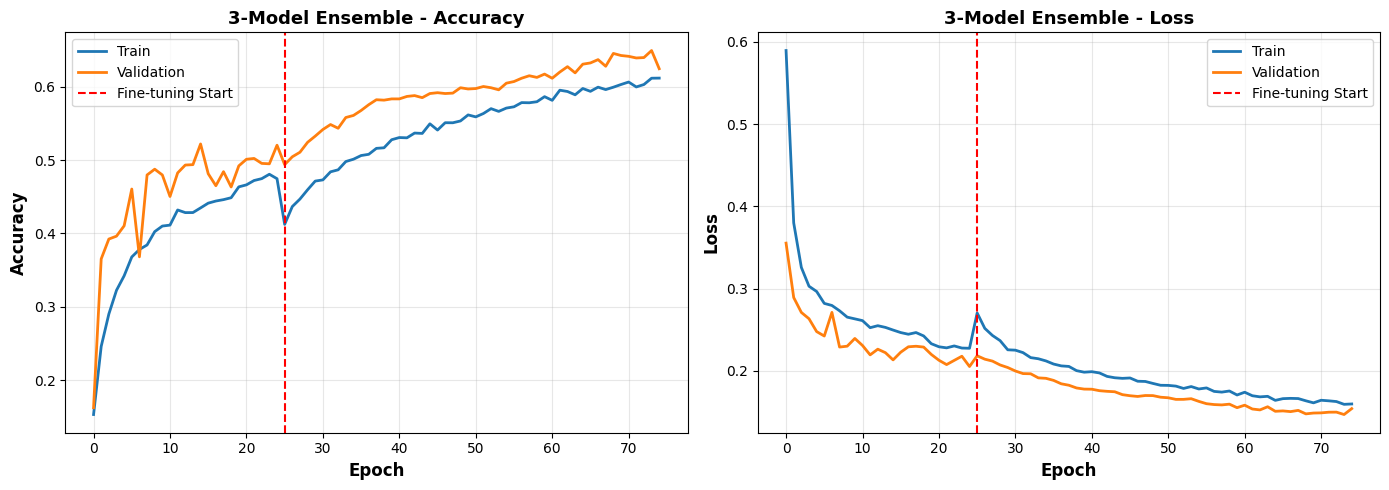

In [ ]:
# Check if phase 1 history exists
phase1_exists = os.path.exists('ensemble3_phase1_history.json')

if phase1_exists:
    # Load both phases
    with open('ensemble3_phase1_history.json', 'r') as f:
        ensemble3_p1_hist = json.load(f)
    with open('ensemble3_phase2_history.json', 'r') as f:
        ensemble3_p2_hist = json.load(f)

    combined_acc_e3 = ensemble3_p1_hist['accuracy'] + ensemble3_p2_hist['accuracy']
    combined_val_acc_e3 = ensemble3_p1_hist['val_accuracy'] + ensemble3_p2_hist['val_accuracy']
    combined_loss_e3 = ensemble3_p1_hist['loss'] + ensemble3_p2_hist['loss']
    combined_val_loss_e3 = ensemble3_p1_hist['val_loss'] + ensemble3_p2_hist['val_loss']
    phase1_epochs = len(ensemble3_p1_hist['accuracy'])
else:
    # Only phase 2 available
    with open('ensemble3_phase2_history.json', 'r') as f:
        ensemble3_p2_hist = json.load(f)

    combined_acc_e3 = ensemble3_p2_hist['accuracy']
    combined_val_acc_e3 = ensemble3_p2_hist['val_accuracy']
    combined_loss_e3 = ensemble3_p2_hist['loss']
    combined_val_loss_e3 = ensemble3_p2_hist['val_loss']
    phase1_epochs = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(combined_acc_e3, label='Train', linewidth=2)
axes[0].plot(combined_val_acc_e3, label='Validation', linewidth=2)
if phase1_exists:
    axes[0].axvline(x=phase1_epochs, color='red',
                    linestyle='--', label='Fine-tuning Start')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('3-Model Ensemble - Accuracy', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(combined_loss_e3, label='Train', linewidth=2)
axes[1].plot(combined_val_loss_e3, label='Validation', linewidth=2)
if phase1_exists:
    axes[1].axvline(x=phase1_epochs, color='red',
                    linestyle='--', label='Fine-tuning Start')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('3-Model Ensemble - Loss', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ensemble3_curves.png', dpi=300, bbox_inches='tight')
plt.show()


### Model Comparison Summary


===== FINAL MODEL COMPARISON =====
                        model  accuracy  precision   recall  f1_score
      Baseline CNN (Original)  0.820200   0.829000 0.820200  0.814800
    Baseline CNN (Fine-tuned)  0.821300   0.831500 0.821300  0.816200
3-Model Ensemble (Focal Loss)  0.723257   0.655172 0.647689  0.640571


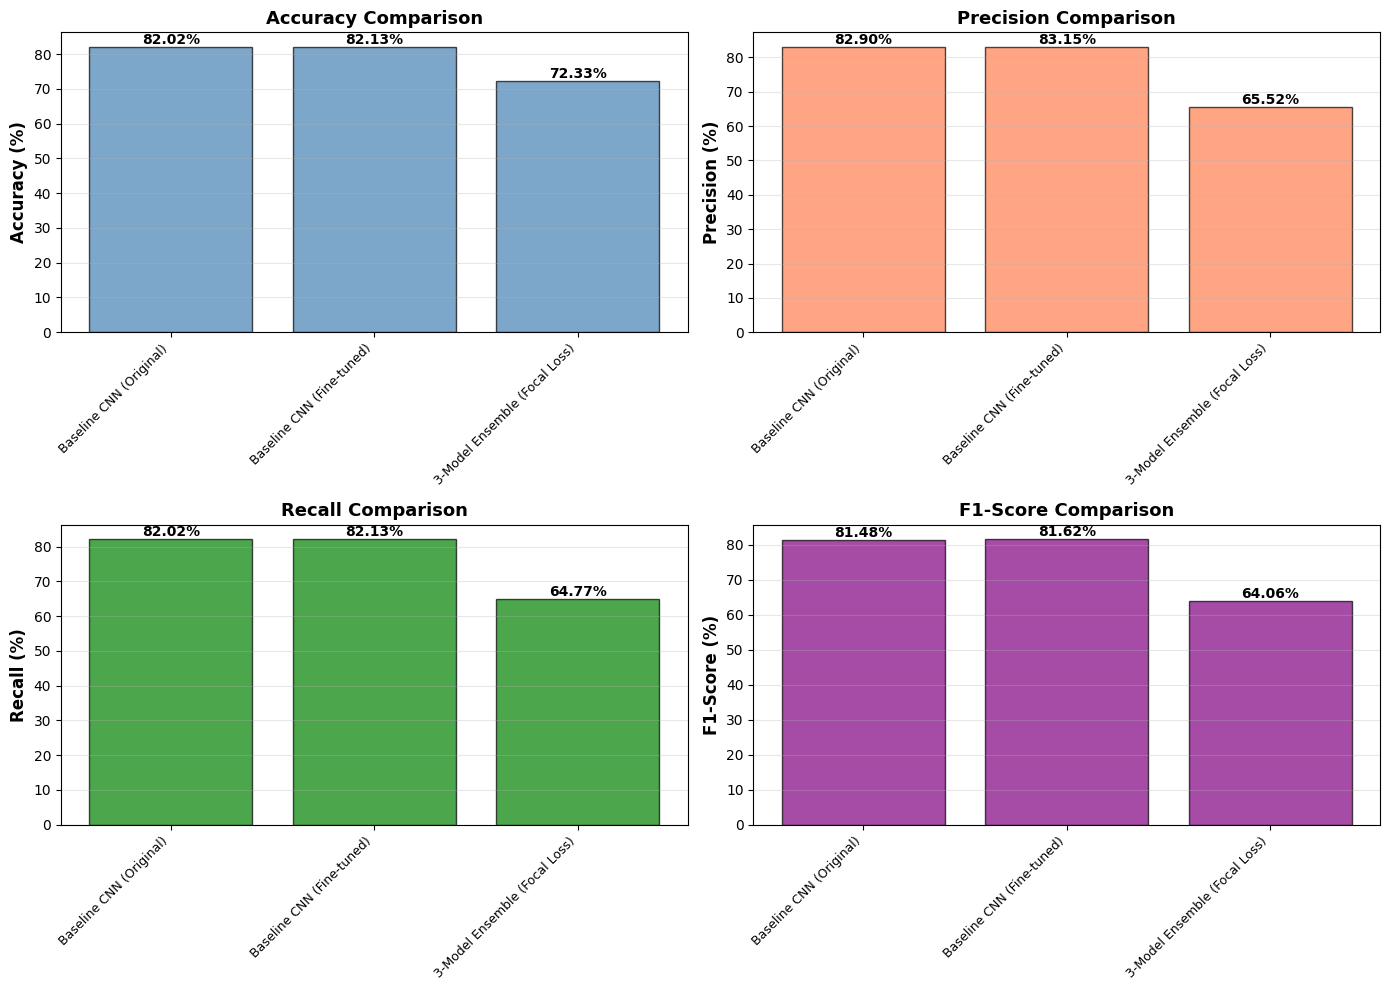

In [ ]:

with open('baseline_cnn_results.json', 'r') as f:
    baseline_results_full = json.load(f)

with open('ensemble3_results.json', 'r') as f:
    ensemble3_results = json.load(f)

# Extract both Baseline models (original + fine-tuned) as separate entries
baseline_original = baseline_results_full['original']
baseline_finetuned = baseline_results_full['finetuned']


model_comparison = pd.DataFrame([
    baseline_original,
    baseline_finetuned,
    ensemble3_results
])

print("\n===== FINAL MODEL COMPARISON =====")
print(model_comparison.to_string(index=False))

# Save comparison as CSV
model_comparison.to_csv('model_comparison.csv', index=False)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'green', 'purple']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx // 2, idx % 2]
    values = model_comparison[metric] * 100
    bars = ax.bar(range(len(model_comparison)), values,
                   color=color, alpha=0.7, edgecolor='black')

    ax.set_ylabel(f'{title} (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{title} Comparison', fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(model_comparison)))
    ax.set_xticklabels(model_comparison['model'], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Add bar values
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h,
                f'{h:.2f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
